# 03 · Prompt sensitivity — $\mathcal{F}(\mathcal{P})$ + $\mathcal{F}_4(\mathcal{E})$

`run_prompt_sensitivity.py` ran a controlled study across three prompt modes
(zero-shot, 2-shot few-shot, chain-of-thought) on 100 seeded samples per task,
holding all other pipeline components fixed.

Aggregated scores are in `outputs/sensitivity_eval/scores.json`
(10 models × 24 tasks × 3 modes). Per-model response JSONL files live in
`outputs/sensitivity_{model}/` for the per-response prompt-failure analysis.


In [1]:
import nbtools as nb
from nbtools import (
    show_df, show_fig, show_md, show_tex,
    run_mod, run_live, heavy,
    REGEN, OUTPUTS_FINAL, OUTPUTS_DIR, PIPELINE_ROOT,
)
import pandas as pd
from IPython.display import display, HTML
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.1f}'.format)

# The 10 models evaluated in the paper (Table 2).
PAPER_MODELS = {
    'Claude Sonnet 4.6':   'claude-sonnet-4-6-cyberxpert',
    'GPT-5.4':             'gpt-5.4',
    'Gemma-4-31B':         'gemma-4-31B-it',
    'Qwen3.6-35B':         'Qwen3.6-35B-A3B',
    'Llama-3.3-70B':       'Llama-3.3-70B-Instruct',
    'GPT-OSS-20B':         'gpt-oss-20b',
    'Primus-Nemotron-70B': 'Llama-Primus-Nemotron-70B',
    'Primus-Merged-8B':    'Llama-Primus-Merged',
    'Foundation-Sec-8B':   'Foundation-Sec-8B-Instruct',
    'RedSage-Qwen3-8B':    'RedSage-Qwen3-8B-DPO',
}

print(f"Data root: {OUTPUTS_FINAL.name}/  — {'OK' if OUTPUTS_FINAL.exists() else 'MISSING'}")

Data root: outputs_final/  — OK


### Load aggregated sensitivity scores

In [2]:
import json, pandas as pd

SCORES_FILE = OUTPUTS_DIR / 'sensitivity_eval' / 'scores.json'
with open(SCORES_FILE) as f:
    raw = json.load(f)

# Only the 10 paper models — fanar2_27b is in the data but not in the paper
MODEL_LABELS = {
    'claude_sonnet_4_6':   'Claude Sonnet 4.6',
    'gpt_5_4':             'GPT-5.4',
    'gemma4_31b':          'Gemma-4-31B',
    'qwen3_35b':           'Qwen3.6-35B',
    'llama33_70b':         'Llama-3.3-70B',
    'gpt_oss_20b':         'GPT-OSS-20B',
    'nemotron_70b':        'Primus-Nemotron-70B',
    'llama_primus_merged': 'Primus-Merged-8B',
    'foundation_sec_8b':   'Foundation-Sec-8B',
    'redsage_qwen3_8b':    'RedSage-Qwen3-8B',
}
records = []
for model, tasks in raw.items():
    if model not in MODEL_LABELS: continue  # skip Fanar and any non-paper models
    if not isinstance(tasks, dict): continue
    for task, modes in tasks.items():
        if not isinstance(modes, dict): continue
        records.append({'model': MODEL_LABELS[model], 'task': task,
                        'zero_shot': modes.get('zero_shot'),
                        'few_shot':  modes.get('few_shot'),
                        'cot':       modes.get('cot')})
df = pd.DataFrame(records).dropna()
df['cot_delta'] = df['cot'] - df['zero_shot']
print(f"{df['model'].nunique()} models  ×  {df['task'].nunique()} tasks")

10 models  ×  22 tasks


### CoT vs zero-shot delta heatmap — F4(E) signature

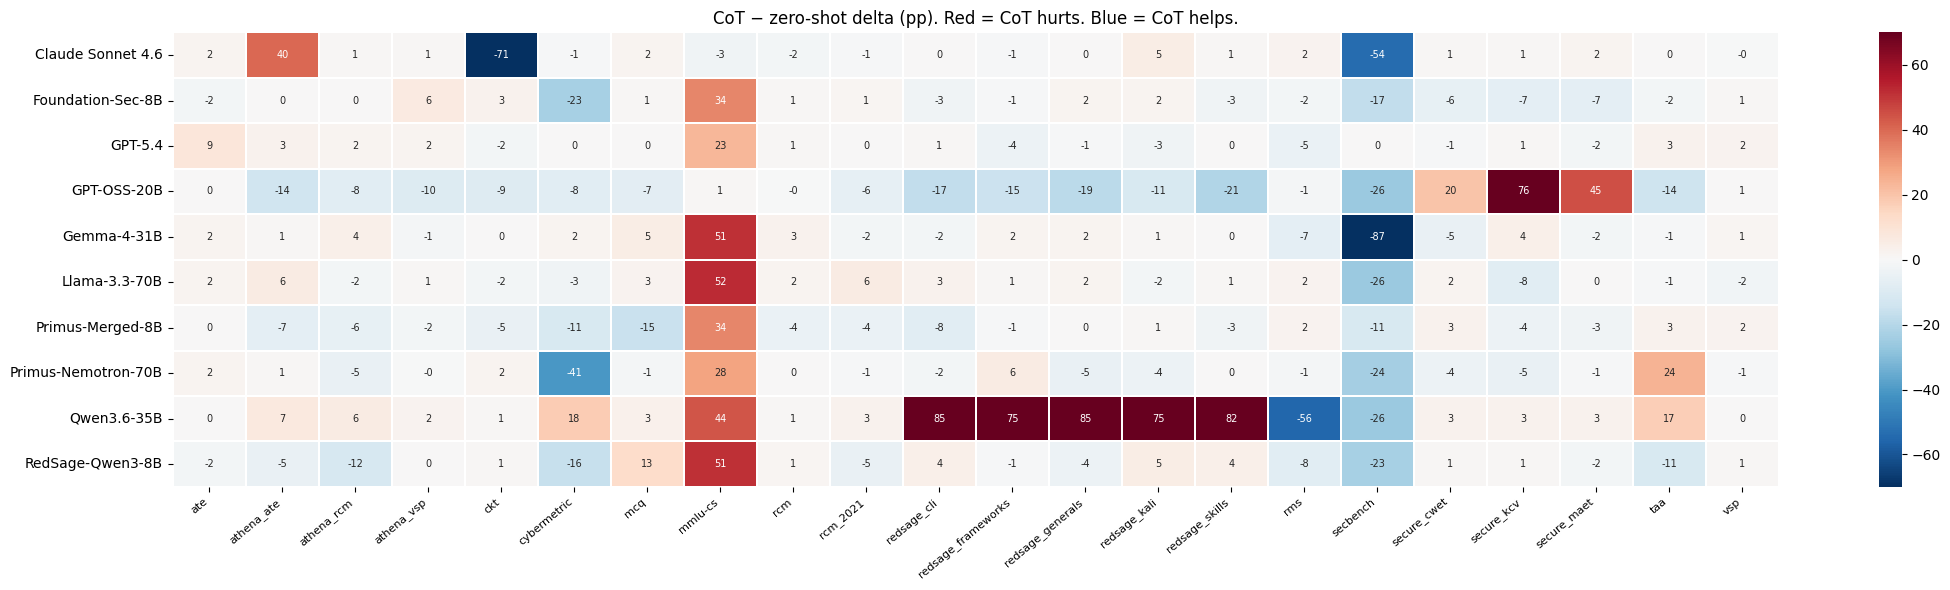

In [3]:
import matplotlib.pyplot as plt, seaborn as sns

pivot = df.pivot_table(index='model', columns='task', values='cot_delta')
pivot = pivot.reindex(sorted(pivot.columns), axis=1)

fig, ax = plt.subplots(figsize=(22, 6))
sns.heatmap(pivot, cmap='RdBu_r', center=0, vmin=-70, vmax=70,
            annot=True, fmt='.0f', annot_kws={'size': 7},
            linewidths=0.3, ax=ax)
ax.set_title('CoT − zero-shot delta (pp). Red = CoT hurts. Blue = CoT helps.')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

### F4(E) case studies — CoT effect by task type

**CoT hurts** on `ckt` and `secbench`: the MCQ extractor (`evaluate.py`) reads only the
final line for a letter answer (A/B/C/D). Under CoT, models often place the answer letter
inside the reasoning body — the final line contains a conclusion sentence, not the letter,
so the extractor scores it wrong.

**CoT helps** on `ate` and `athena_ate`: the ATE extractor (`ctibench_format_ate` in
`evaluate.py`) tries the final line first but **falls back to a full-text scan** for MITRE
T-IDs if the last line is empty. Under CoT, models mention technique IDs throughout the
reasoning trace — the full-text fallback finds them even when the last line lacks IDs.

The same CoT output scores differently depending purely on which extractor is applied.


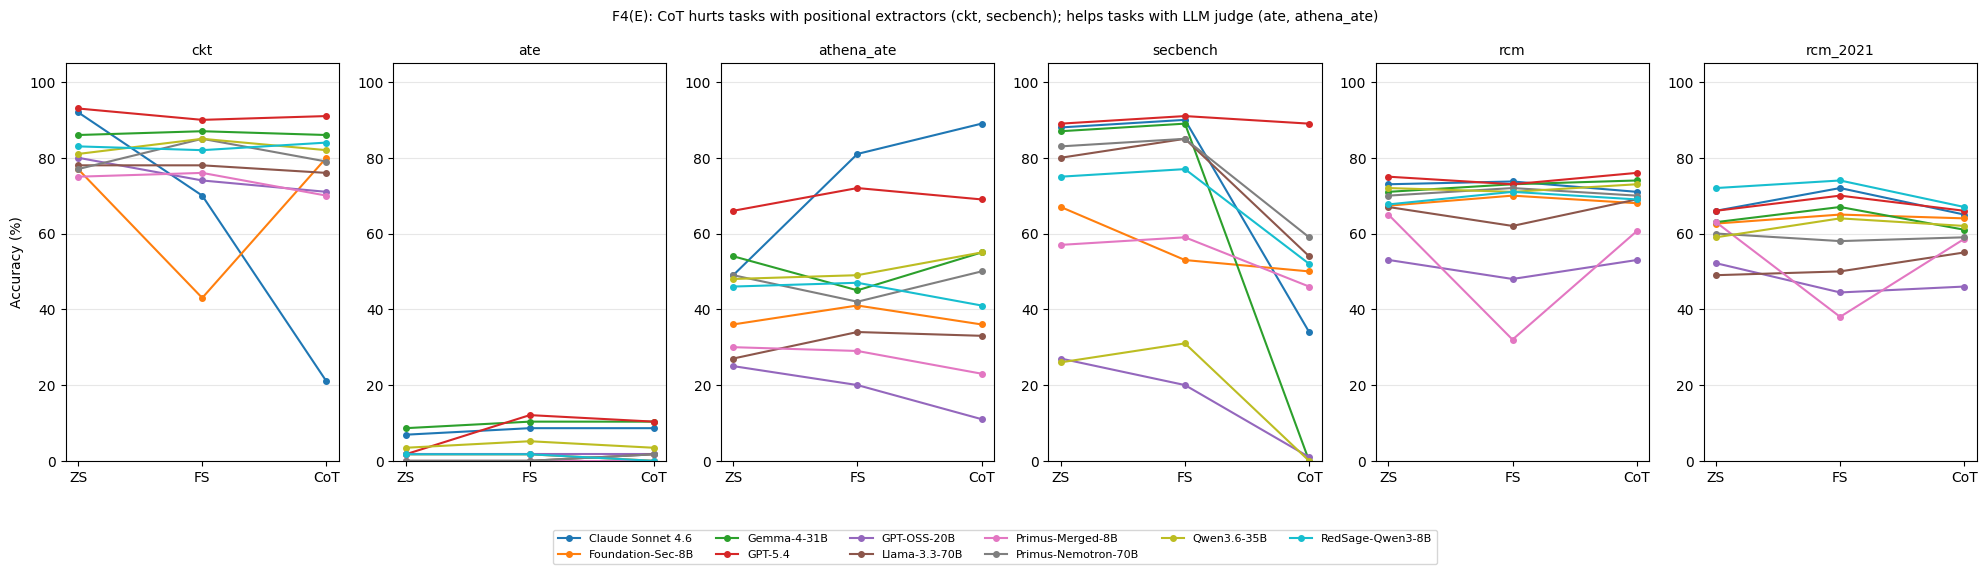

In [4]:
import matplotlib.pyplot as plt
import numpy as np

focus  = ['ckt', 'ate', 'athena_ate', 'secbench', 'rcm', 'rcm_2021']
modes  = ['zero_shot', 'few_shot', 'cot']
mlabels = ['ZS', 'FS', 'CoT']
colors  = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(focus), figsize=(20, 5))
for ax, task in zip(axes, focus):
    tdf = df[df['task'] == task].reset_index(drop=True)
    for i, row in tdf.iterrows():
        ax.plot(mlabels, [row[m] for m in modes],
                marker='o', color=colors[i % 10],
                label=row['model'], lw=1.5, ms=4)
    ax.set_title(task, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)' if task == focus[0] else '')
    ax.grid(axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.14))
fig.suptitle('F4(E): CoT hurts tasks with positional extractors (ckt, secbench);'
             ' helps tasks with LLM judge (ate, athena_ate)', fontsize=10)
plt.tight_layout(); plt.show()

### F2(P): Prompt–question conflict — single-letter rate on SecEval  *(light · response JSONL)*

In [5]:
import json, re

for short, full_dir in [
    ('foundation_sec_8b', 'sensitivity_foundation_sec_8b'),
    ('llama33_70b',       'sensitivity_llama33_70b'),
    ('claude_sonnet_4_6', 'sensitivity_claude_sonnet_4_6'),
]:
    jsonl = OUTPUTS_DIR / full_dir / 'seceval_zero_shot_responses.jsonl'
    if jsonl.exists():
        rows = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]
        single = sum(1 for r in rows
                     if len(set(re.findall(r'[A-D]', str(r.get('model_response',''))))) == 1)
        label = MODEL_LABELS.get(short, short)
        print(f"F2(P) {label:<30}: {single}/{len(rows)} single-letter ({100*single/len(rows):.1f}%)")
    else:
        print(f"[missing] {jsonl.name} — run run_prompt_sensitivity.py for {short}")

F2(P) Foundation-Sec-8B             : 71/100 single-letter (71.0%)
F2(P) Llama-3.3-70B                 : 60/100 single-letter (60.0%)
F2(P) Claude Sonnet 4.6             : 38/100 single-letter (38.0%)


### Sensitivity table — Zero-shot / Few-shot / CoT per model × task

**Experimental setup:** `run_prompt_sensitivity.py` evaluated 100 randomly-seeded samples
per task under three prompt configurations, holding all other pipeline components fixed
(same model, same decoding parameters, same token budgets, same extractor):

- **ZS (Zero-shot):** Original benchmark prompt, no demonstrations
- **FS (Few-shot):** 2 held-out in-distribution examples prepended to the prompt
- **CoT (Chain-of-thought):** Extended reasoning budget appended to the system prompt

All three modes were evaluated on the **same 100 samples per task** (seeded split),
so differences between columns are attributable purely to prompt specification (𝒫).

Δ = CoT − ZS. **Negative Δ** = CoT hurts; **Positive Δ** = CoT helps.


In [6]:
# Pivot: models as rows, tasks as columns
# Two tables: zero-shot scores, and CoT delta (CoT − zero-shot)

TASK_ORDER = [
    ('mcq','MCQ'),('rcm','RCM'),('ate','ATE'),('taa','TAA'),
    ('ckt','CKT'),('rms','RMS'),('athena_ate','ATE-A'),('athena_rcm','RCM-A'),('athena_vsp','VSP-A'),
    ('secure_maet','MAET'),('secure_cwet','CWET'),('secure_kcv','KCV'),
    ('seceval','SecEval'),('cybermetric','CyberMet'),('mmlu-cs','MMLU'),('secbench','SecBench'),
    ('redsage_cli','RS-CLI'),('redsage_frameworks','RS-FW'),('redsage_generals','RS-GEN'),
    ('redsage_kali','RS-Kali'),('redsage_skills','RS-Skills'),
]
BENCH_COLS = {
    'MCQ':'CTI','RCM':'CTI','ATE':'CTI','TAA':'CTI',
    'CKT':'Ath','RMS':'Ath','ATE-A':'Ath','RCM-A':'Ath','VSP-A':'Ath',
    'MAET':'SEC','CWET':'SEC','KCV':'SEC',
    'SecEval':'Gen','CyberMet':'Gen','MMLU':'Gen','SecBench':'Gen',
    'RS-CLI':'RS','RS-FW':'RS','RS-GEN':'RS','RS-Kali':'RS','RS-Skills':'RS',
}

task_keys  = [k for k, _ in TASK_ORDER if k in df['task'].unique()]
task_names = [n for k, n in TASK_ORDER if k in df['task'].unique()]
model_list = df['model'].unique()

def make_mode_table(col):
    rows = {}
    for model in model_list:
        row = {}
        for key, name in zip(task_keys, task_names):
            r = df[(df['model'] == model) & (df['task'] == key)]
            if not r.empty:
                v = r.iloc[0][col]
                row[name] = round(float(v), 1) if v is not None and str(v) != 'nan' else None
            else:
                row[name] = None
        rows[model] = row
    result = pd.DataFrame(rows).T
    result.index.name = 'Model'
    midx = pd.MultiIndex.from_tuples(
        [(BENCH_COLS.get(n,'?'), n) for n in task_names], names=['Benchmark','Task']
    )
    result.columns = midx
    return result

zs_df    = make_mode_table('zero_shot')
fs_df    = make_mode_table('few_shot')
cot_df   = make_mode_table('cot')
delta_df = make_mode_table('cot_delta')

def show_table(tbl, title):
    fmt = lambda v: f'{v:+.1f}' if isinstance(v,(int,float)) and 'delta' in title.lower() else (f'{v:.1f}' if isinstance(v,(int,float)) else '—')
    print(title)
    display(tbl.fillna('—').style
            .format(lambda v: f'{v:+.1f}' if isinstance(v,(int,float)) and 'Δ' in title else (f'{v:.1f}' if isinstance(v,(int,float)) else '—'),
                    na_rep='—')
            .set_table_styles([
                {'selector':'th','props':[('font-size','9px'),('padding','3px 5px'),('text-align','center'),('white-space','nowrap')]},
                {'selector':'td','props':[('font-size','9px'),('padding','2px 5px'),('text-align','center')]},
                {'selector':'caption','props':[('font-weight','bold'),('font-size','11px'),('padding','6px 0')]},
            ])
            .set_caption(title))

show_table(zs_df,    'Zero-shot (ZS) accuracy %')
show_table(fs_df,    'Few-shot (FS) accuracy %')
show_table(cot_df,   'Chain-of-thought (CoT) accuracy %')
show_table(delta_df, 'Δ = CoT − Zero-shot (pp)  |  negative = CoT hurts  |  positive = CoT helps')

Zero-shot (ZS) accuracy %


Few-shot (FS) accuracy %


Chain-of-thought (CoT) accuracy %


Δ = CoT − Zero-shot (pp)  |  negative = CoT hurts  |  positive = CoT helps
